## Practice 15 - Dimensionality Reduction
In this lab we will use Dimensionality Reduction methods for classification. \
Based on Chapter 8 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice15DimRed.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [28]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

### Exercise 1: 
Using the data set in 3 dimensions generated by the code below:\
a) Take its SVD, check you can reconstruct the original data (using np).\
b) Make zero one of the eigenvalues and do the same reconstruction. Plot in 3D \
c) Do a projection onto the principal axes using all dimensions. Use numpy first then sklearn.\
d) Do a projection onto the two principal axes only. Plot in 2D.\
e) Do a reconstruction in 3D from the 2D projection. Plot in 3D.

In [29]:
from mpl_toolkits import mplot3d

In [30]:
# You can experiement with your own data set for three-dimensional scattered points
# zdata = 15 * np.random.random(100)
# xdata = np.sin(zdata) + 0.1 * np.random.randn(100)
# ydata = np.cos(zdata) + 0.1 * np.random.randn(100)

In [31]:
# put the three arrays into a 2D matrix for SVD operations
# X=np.concatenate([xdata,ydata,zdata]).reshape(3,100).T
# print(X.shape)
# fig = plt.figure()
# ax = plt.axes(projection='3d')
# ax.scatter3D(X[:,0],X[:,1], X[:,2],c=X[:,2], cmap='Greens');
#plt.show()

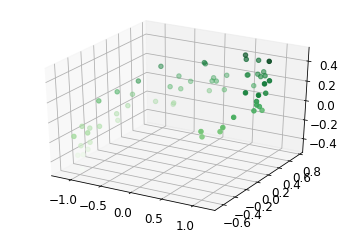

In [64]:
np.random.seed(4)
m = 60
w1, w2 = 0.1, 0.3
noise = 0.1
angles = np.random.rand(m) * 3 * np.pi / 2 - 0.5
X = np.empty((m, 3))
X[:, 0] = np.cos(angles) + np.sin(angles)/2 + noise * np.random.randn(m) / 2
X[:, 1] = np.sin(angles) * 0.7 + noise * np.random.randn(m) / 2
X[:, 2] = X[:, 0] * w1 + X[:, 1] * w2 + noise * np.random.randn(m)
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(X[:,0],X[:,1], X[:,2],c=X[:,2], cmap='Greens');
plt.show()

We can use numpy.linalg.svd:\
${\bf U,S,V}=svd(X)$ implies that $\bf X= U S V^T$

In [65]:
XC = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(XC)
c1 = Vt.T[:, 0]
c2 = Vt.T[:, 1]
print("V=",Vt.T)
print(c1)

V= [[ 0.93636116 -0.34027485 -0.08626012]
 [ 0.29854881  0.90119108 -0.31420255]
 [ 0.18465208  0.2684542   0.94542898]]
[0.93636116 0.29854881 0.18465208]


In [66]:
print(U.shape)
print(s.shape)
print(Vt.shape)

(60, 60)
(3,)
(3, 3)


reconstruct X by multiplying the SVD components. Notice the "@" for matrix multiplication instead of "*".\
s is a vector, we need a matrix size (3,3)

In [67]:
import scipy.linalg as la
S=la.diagsvd(s,*X.shape)
XR=U@S@Vt
print("reconstruction error between %1.1e and %1.1e"%((XR - XC).min(), (XR-XC).max()))

reconstruction error between -8.9e-16 and 6.7e-16


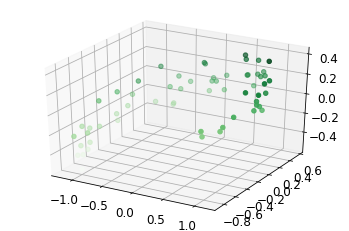

In [68]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(XR[:,0],XR[:,1], XR[:,2],c=XR[:,2], cmap='Greens');
plt.show()

Original [6.77645005 2.82403671 0.78116597]
New s [6.77645005 2.82403671 0.        ]
-0.1918717152600699
0.18336302769111873


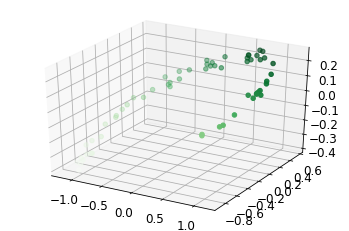

In [69]:
# now let eliminate one of the 3 dimensions by making the smaller singular value equal to 0
print('Original',s)
ss=s
ss[2]=0;
print('New s',ss)
SS=la.diagsvd(ss,*X.shape)
XR2=U@SS@Vt
print((XR2 - XC).min())
print((XR2 - XC).max())
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(XR2[:,0],XR2[:,1], XR2[:,2],c=XR2[:,2], cmap='Greens');
plt.show()

We see now the points are scattered along a plane (2D) embeded in 3D.

8.881784197001252e-16
-6.661338147750939e-16


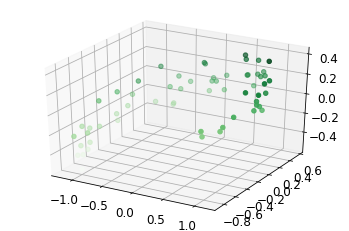

In [71]:
#another way with numpy (without using scipy)
XC = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(XC)
m, n = X.shape
S = np.zeros(XC.shape)
S[:n, :n] = np.diag(s)
XR = U.dot(S).dot(Vt)
print((XC-XR).max())
print((XC-XR).min())
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(XR[:,0],XR[:,1], XR[:,2],c=XR[:,2], cmap='Greens');

To map the volume into 3D, in general we just multiply the reconstructed $XR$ by $V$.\
This is each vector in the data set is projected along the V vectors that form the basis functions of 3D.\
Each column of U is a basis function of the data space.\
Each column of V is a basis function of the model space.\
Each element of S is the strength of the mapping between data and model.\
By eliminating one component of S or one vector of V we are reducing dimensionality.\
(when multiplying $C = A * B^T$ using matrix product, each column of C is the projection (dot product)\
of one column of A with a column of B)

In [87]:
print(Vt.T[:,:3])

[[ 0.93636116 -0.34027485 -0.08626012]
 [ 0.29854881  0.90119108 -0.31420255]
 [ 0.18465208  0.2684542   0.94542898]]


Just to clarify, you can use either @ or .dot when multiplying matrices

In [88]:
error=(XC.dot(Vt.T)-XC@Vt.T)
print(error.shape, error.min(), error.max())

(60, 3) 0.0 0.0


(60, 3)


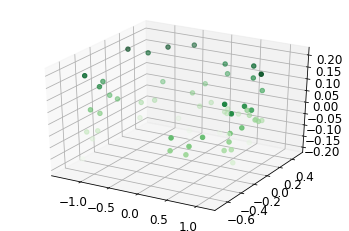

In [89]:
# let us do a projection on 3D
W2 = Vt.T[:, :3]
X3D = XC.dot(W2)
print(X3D.shape)
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(X3D[:,0],X3D[:,1], X3D[:,2],c=X3D[:,2], cmap='Greens');
plt.show()

### Using sklearn PCA
Using scikit-learn is of course easier since the this code is already implemented into the PCA class\
using the familiar interface "fit_transform()" that we normally use.

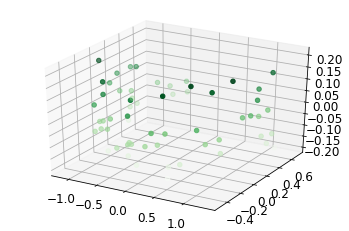

In [90]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 3)
X3D = pca.fit_transform(X)
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(X3D[:,0],X3D[:,1], X3D[:,2],c=X3D[:,2], cmap='Greens');
plt.show()

We can see the projection in 2D by projecting the data onto the two main vectors of V.\
(using the dot product, column by column)

(60, 2)


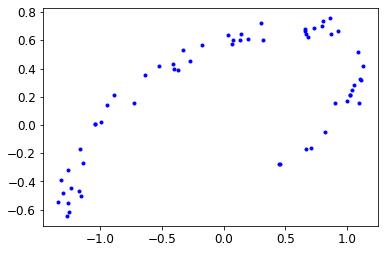

In [91]:
W2 = Vt.T[:, :2]
X2D = XC.dot(W2)
print(X2D.shape)
fig = plt.figure()
plt.plot(X2D[:,0],X[:,1],'b.')
plt.show()

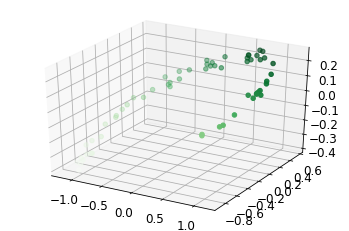

In [92]:
X3D_inv = X2D.dot(Vt[:2, :])
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(X3D_inv[:,0],X3D_inv[:,1], X3D_inv[:,2],c=X3D_inv[:,2], cmap='Greens');
plt.show()

(60, 2)


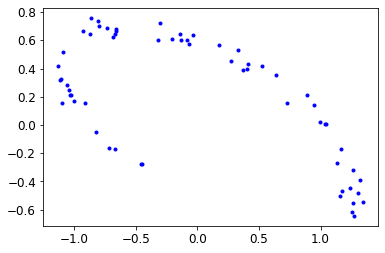

In [93]:
pca = PCA(n_components = 2)
X2D = pca.fit_transform(X)
print(X2D.shape)
fig = plt.figure()
plt.plot(X2D[:,0],X[:,1],'b.')
plt.show()

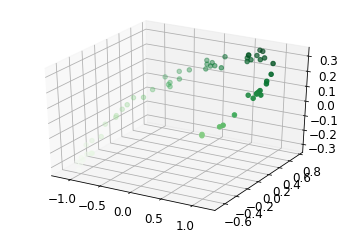

In [94]:
X3D_inv = pca.inverse_transform(X2D)
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(X3D_inv[:,0],X3D_inv[:,1], X3D_inv[:,2],c=X3D_inv[:,2], cmap='Greens');
plt.show()

### Exercise 2: Manifold Learning
Use the Swiss roll data generated below:\
a) Remove one of the dimensions by squeezing it.\
b) Remove one of the dimensions by using the values as parameters.\
c) Apply dimensionality reduction to 2 components using PCA\
d) Apply dimensionality reduction to 2 components using linear PCA\
e) Apply dimensionality reduction to 2 components using Kernel PCA


In [95]:
from sklearn.datasets import make_swiss_roll
X, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

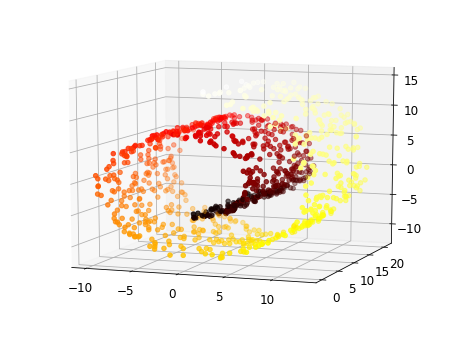

In [96]:
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection='3d')
ax.scatter3D(X[:,0],X[:,1], X[:,2],c=t, cmap=plt.cm.hot);
ax.view_init(10, -70)
plt.show()

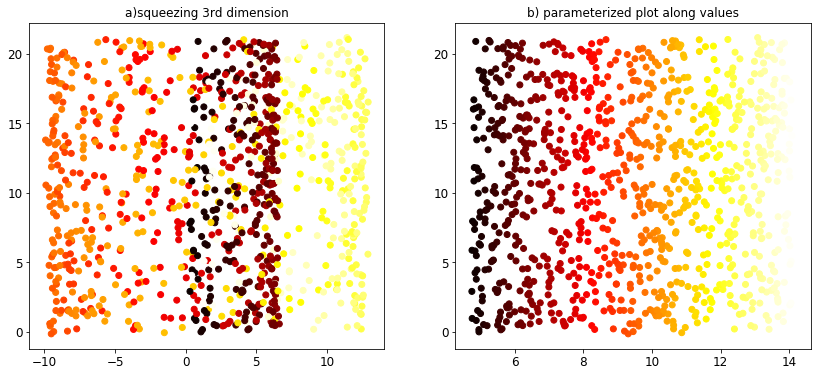

In [97]:
fig = plt.figure(figsize=(14,6))
plt.subplot(121)
plt.scatter(X[:,0],X[:,1],c=t, cmap=plt.cm.hot);
plt.title("a)squeezing 3rd dimension")
plt.subplot(122)
plt.scatter(t,X[:,1],c=t, cmap=plt.cm.hot);
plt.title("b) parameterized plot along values")
plt.show()

(1000, 2)


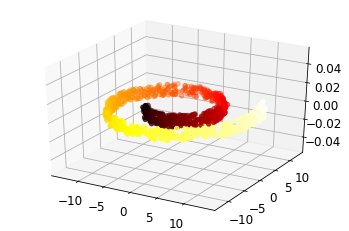

In [98]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X2D = pca.fit_transform(X)
print(X2D.shape)
fig = plt.figure()
ax = plt.axes(projection='3d')
#ax.scatter(X2D[:,0],X2D[:,1],X2D[:,2],c=t, cmap=plt.cm.hot);
ax.scatter(X2D[:,0],X2D[:,1],c=t, cmap=plt.cm.hot);
plt.show()

Text(0.5, 1.0, 'c) PCA')

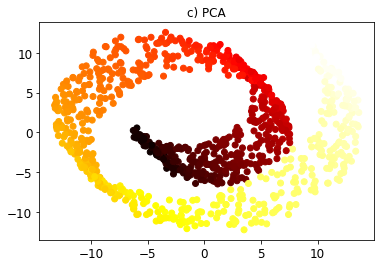

In [99]:
fig = plt.figure()
plt.scatter(X2D[:,0],X2D[:,1],c=t, cmap=plt.cm.hot)
plt.title("c) PCA")

Text(0.5, 1.0, 'd) linear PCA')

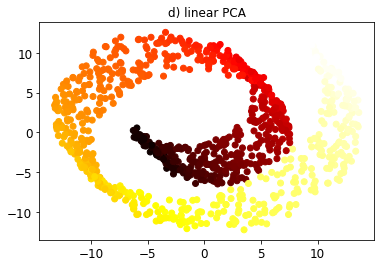

In [100]:
from sklearn.decomposition import KernelPCA
lin_pca = KernelPCA(n_components = 2, kernel="linear", fit_inverse_transform=True)
X2Db = lin_pca.fit_transform(X)
fig = plt.figure()
plt.scatter(X2Db[:,0],X2Db[:,1],c=t, cmap=plt.cm.hot)
plt.title("d) linear PCA")

Text(0.5, 1.0, 'e) Kernel PCA')

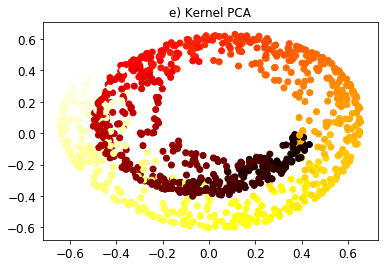

In [101]:
from sklearn.decomposition import KernelPCA
rbf_pca = KernelPCA(n_components = 2, kernel="rbf", gamma=0.004,fit_inverse_transform=True)
X2Dc = rbf_pca.fit_transform(X)
fig = plt.figure()
plt.scatter(X2Dc[:,0],X2Dc[:,1],c=t, cmap=plt.cm.hot)
plt.title("e) Kernel PCA")